In [19]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam



In [ ]:
# Load the dataset 
df = pd.read_csv('C:\\Users\\MOJ\\Desktop\\semester 2\\ML Capstone Project\\data\\IMDB Dataset.csv')
print(df.head()) # Check the first 5 rows of the dataset


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


KeyError: 'clean_review'

Missing values:
review       0
sentiment    0
dtype: int64
                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]

Sentiment counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Positive: 25000 (50

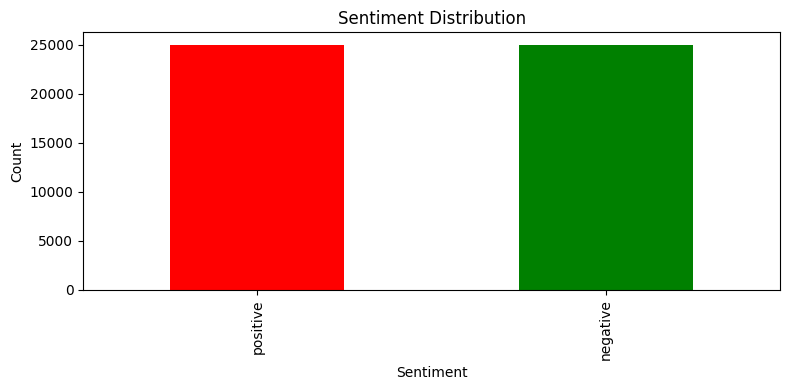

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(df.dropna())  # drop missing values 

# Count positive and negative reviews
print("\nSentiment counts:")
print(df['sentiment'].value_counts())

# Show as percentage
pos = (df['sentiment'] == 'positive').sum()
neg = (df['sentiment'] == 'negative').sum()
print(f"\nPositive: {pos} ({pos/len(df)*100:.1f}%)")
print(f"Negative: {neg} ({neg/len(df)*100:.1f}%)")

# Plot distribution
plt.figure(figsize=(8, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

In [4]:
# Download stopwords (common words like "the", "a", "an" to remove)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MOJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
# Function to clean text
def clean_text(text):
    # Make lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<br />', ' ', text)
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Split into words
    words = text.split()
    # Remove stopwords and short words
    words = [w for w in words if w not in stop_words and len(w) > 2]
    # Join back together
    return ' '.join(words)

# Apply cleaning to all reviews
df['clean_review'] = df['review'].apply(clean_text)
print("Text cleaned")

# Show example
print(f"\nOriginal: {df['review'].iloc[0][:200]}")
print(f"Cleaned: {df['clean_review'].iloc[0][:200]}")


Text cleaned

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
Cleaned: one reviewers mentioned watching episode youll hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches r


In [6]:
# Convert sentiment to numbers (0 = negative, 1 = positive)
y = (df['sentiment'] == 'positive').astype(int)

# Convert words to numbers
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

print(f"Shape: {X.shape}")
print(f"Positive: {y.sum()}")
print(f"Negative: {len(y) - y.sum()}")

Shape: (50000, 5000)
Positive: 25000
Negative: 25000


In [7]:
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]}")
print(f"Testing: {X_test.shape[0]}")

Training: 40000
Testing: 10000


In [8]:
# Train Logistic Regression
print("Training Logistic Regression...")
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

# Calculate metrics
acc1 = accuracy_score(y_test, pred1)
prec1 = precision_score(y_test, pred1)
rec1 = recall_score(y_test, pred1)
f1_1 = f1_score(y_test, pred1)

print(f"Accuracy: {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall: {rec1:.4f}")
print(f"F1-Score: {f1_1:.4f}")

Training Logistic Regression...
Accuracy: 0.8893
Precision: 0.8831
Recall: 0.8974
F1-Score: 0.8902


In [9]:
# Train Random Forest
print("Training Random Forest...")
model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

# Calculate metrics
acc2 = accuracy_score(y_test, pred2)
prec2 = precision_score(y_test, pred2)
rec2 = recall_score(y_test, pred2)
f1_2 = f1_score(y_test, pred2)

print(f"Accuracy: {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall: {rec2:.4f}")
print(f"F1-Score: {f1_2:.4f}")

Training Random Forest...
Accuracy: 0.8520
Precision: 0.8602
Recall: 0.8406
F1-Score: 0.8503


In [10]:
# Train KNN
print("Training KNN...")
model3 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)

# Calculate metrics
acc3 = accuracy_score(y_test, pred3)
prec3 = precision_score(y_test, pred3)
rec3 = recall_score(y_test, pred3)
f1_3 = f1_score(y_test, pred3)

print(f"Accuracy: {acc3:.4f}")
print(f"Precision: {prec3:.4f}")
print(f"Recall: {rec3:.4f}")
print(f"F1-Score: {f1_3:.4f}")

Training KNN...
Accuracy: 0.7435
Precision: 0.7139
Recall: 0.8126
F1-Score: 0.7601


In [11]:
# Create comparison table
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [acc1, acc2, acc3],
    'Precision': [prec1, prec2, prec3],
    'Recall': [rec1, rec2, rec3],
    'F1-Score': [f1_1, f1_2, f1_3]
})

print("\nAll Models Comparison:")
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['F1-Score'].idxmax()
print(f"\nBest Model: {results_df.iloc[best_idx]['Model']}")

# Save results
results_df.to_csv('model_results.csv', index=False)


All Models Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8893   0.883094  0.8974  0.890189
      Random Forest    0.8520   0.860213  0.8406  0.850293
                KNN    0.7435   0.713934  0.8126  0.760079

Best Model: Logistic Regression


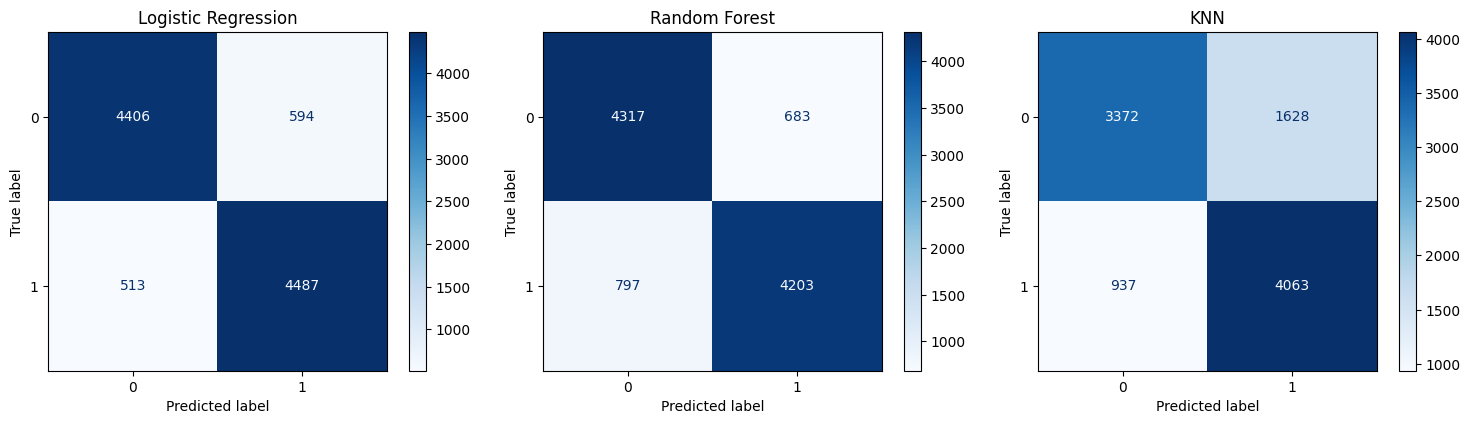

In [12]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Logistic Regression', pred1), ('Random Forest', pred2), ('KNN', pred3)]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [13]:
# Convert sparse to dense for neural network
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print(f"Training shape: {X_train_dense.shape}")
print(f"Test shape: {X_test_dense.shape}")

Training shape: (40000, 5000)
Test shape: (10000, 5000)


In [14]:
# Build neural network
print("Building neural network...")
model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
model_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural network built")
model_nn.summary()

Building neural network...

Neural network built
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               640128    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_

In [15]:
# Train neural network
print("Training neural network...")
history = model_nn.fit(
    X_train_dense, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Training completed")

Training neural network...
Epoch 1/15


1000/1000 [==============================] - 21s 17ms/step - loss: 0.3412 - accuracy: 0.8537 - val_loss: 0.2730 - val_accuracy: 0.8841
Epoch 2/15
1000/1000 [==============================] - 16s 16ms/step - loss: 0.2264 - accuracy: 0.9099 - val_loss: 0.2806 - val_accuracy: 0.8827
Epoch 3/15
1000/1000 [==============================] - 16s 16ms/step - loss: 0.1571 - accuracy: 0.9417 - val_loss: 0.3442 - val_accuracy: 0.8804
Epoch 4/15
1000/1000 [==============================] - 17s 17ms/step - loss: 0.0856 - accuracy: 0.9713 - val_loss: 0.3940 - val_accuracy: 0.8785
Epoch 5/15
1000/1000 [==============================] - 15s 15ms/step - loss: 0.0426 - accuracy: 0.9865 - val_loss: 0.5065 - val_accuracy: 0.8754
Epoch 6/15
1000/1000 [==============================] - 16s 16ms/step - loss: 0.0256 - accuracy: 0.9918 - val_loss: 0.6349 - val_accuracy: 0.8723
Epoch 7/15
1000/1000 [==============================] - 15s 15ms/step - loss: 0.0210 - accuracy

In [16]:
# Evaluate on test set
print("Evaluating neural network...")
nn_loss, nn_acc = model_nn.evaluate(X_test_dense, y_test, verbose=0)
nn_pred = (model_nn.predict(X_test_dense) > 0.5).astype(int).flatten()

nn_prec = precision_score(y_test, nn_pred)
nn_rec = recall_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

print(f"Accuracy: {nn_acc:.4f}")
print(f"Precision: {nn_prec:.4f}")
print(f"Recall: {nn_rec:.4f}")
print(f"F1-Score: {nn_f1:.4f}")

Evaluating neural network...
313/313 [==============================] - 2s 6ms/step
Accuracy: 0.8682
Precision: 0.8564
Recall: 0.8848
F1-Score: 0.8704


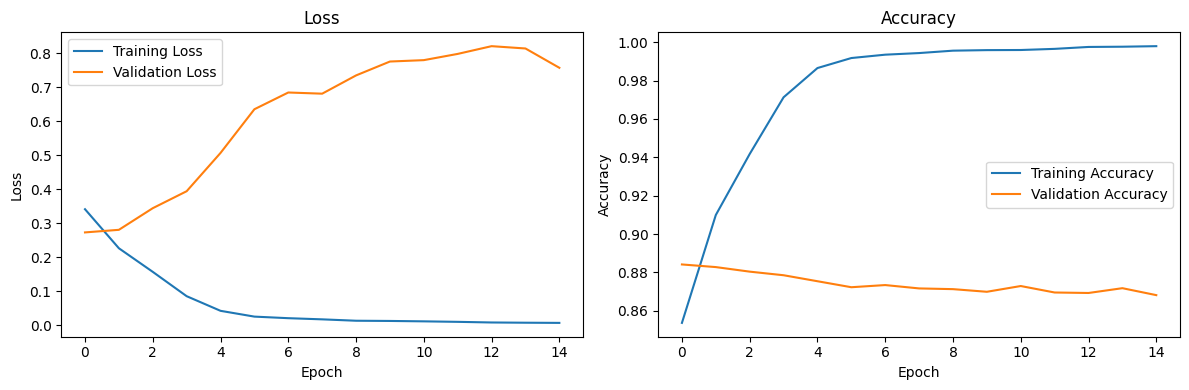

In [17]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [18]:
# Add neural network to comparison
nn_row = pd.DataFrame({
    'Model': ['Neural Network'],
    'Accuracy': [nn_acc],
    'Precision': [nn_prec],
    'Recall': [nn_rec],
    'F1-Score': [nn_f1]
})

final_results = pd.concat([results_df, nn_row], ignore_index=True)

print("\nFinal Results - All Models:")
print(final_results.to_string(index=False))

# Find best
best_final = final_results.loc[final_results['F1-Score'].idxmax()]
print(f"\nBest Model: {best_final['Model']}")
print(f"F1-Score: {best_final['F1-Score']:.4f}")

# Save
final_results.to_csv('final_results.csv', index=False)
print("Results saved")


Final Results - All Models:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8893   0.883094  0.8974  0.890189
      Random Forest    0.8520   0.860213  0.8406  0.850293
                KNN    0.7435   0.713934  0.8126  0.760079
     Neural Network    0.8682   0.856369  0.8848  0.870352

Best Model: Logistic Regression
F1-Score: 0.8902
Results saved
